In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from Bio.Seq import Seq

from netam.models import DEFAULT_NEUTRAL_MODEL

from dnsmex.dxsm_data import pcp_df_of_nickname
from dnsmex.local import localify
from dnsmex.neutral_mutability import CachedMutabilityContainer


figures_dir = localify("FIGURES_DIR")
neutral_model_name = DEFAULT_NEUTRAL_MODEL

Neutral rates container is loaded from dnsmex.neutral_mutability.
Site numbering is all IMGT aligned.

Initial run on the v1rodriguez dataset took 30 minutes, but the output is cached and next run goes quickly. Also possible to load only a subset of the df with "container = CachedMutabilityContainer("v1rodriguez", subset_size=1000)"


### Mutability analysis

In [2]:
MutabilityContainer = CachedMutabilityContainer(dataset="v1rodriguez", neutral_model_name=DEFAULT_NEUTRAL_MODEL)



Loading MutabilityContainer data from gzip cache...
✓ Loaded from gzip cache:
  - Nucleotide DataFrame: 31,756,452 rows
  - Amino Acid DataFrame: 18,723,268 rows
  - Amino Acid to Any DataFrame: 2,646,371 rows
  - Codon DataFrame: 26,463,710 rows
  - Codon to Any DataFrame: 2,646,371 rows
  - PCP DataFrame: 21,752 rows


In [3]:
MutabilityContainer.pcp_df["v_gene"].value_counts().head(5)

v_gene
IGHV3-23*01    1905
IGHV3-74*01    1082
IGHV4-39*01    1049
IGHV1-69*01    1025
IGHV3-7*01      909
Name: count, dtype: int64

In [4]:
# plotting and aggregating functions

def plot_mutability_with_highlights(nuc_neutral_df, highlight_sites, figsize=(10, 4)):
    """
    Plot neutral mutability prediction with highlighted amino acid sites.
    
    Parameters:
    -----------
    highlight_sites : list
        List of amino acid site numbers to highlight on the plot
    figsize : tuple, default (12, 6)
        Figure size (width, height) in inches
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure object
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Get aggregated mutability data per nucleotide site
    # This aggregates across all sequences and transition nucleotides
    mutability_data = (nuc_neutral_df
                      .groupby('nuc_site')['rate']
                      .mean()
                      .reset_index())
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot the main mutability line
    ax.plot(mutability_data['nuc_site'], 
            mutability_data['rate'], 
            color='gray', 
            alpha=0.7, 
            linewidth=1,
            label='Mutability')
    
    # Add highlights for specified amino acid sites
    if highlight_sites:
        # Get nucleotide positions corresponding to amino acid sites
        # Assuming standard codon structure: AA site N corresponds to nucleotides 3*(N-1), 3*(N-1)+1, 3*(N-1)+2
        for aa_site in highlight_sites:
            # Calculate the three nucleotide positions for this amino acid

            nuc_positions = nuc_neutral_df[nuc_neutral_df.site == aa_site].nuc_site.unique()
            
            # Get mutability values for these positions
            highlight_data = mutability_data[mutability_data['nuc_site'].isin(nuc_positions)]
            
            if not highlight_data.empty:
                ax.scatter(highlight_data['nuc_site'], 
                          highlight_data['rate'],
                          color='blue', 
                          s=50, 
                          zorder=5,
                          label=f'AA Site {aa_site}' if aa_site == highlight_sites[0] else "")
    
    # Customize the plot
    ax.set_xlabel('Nucleotide Site')
    ax.set_ylabel('Mutability')
    ax.set_title('Neutral mutability prediction')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Set reasonable y-axis limits
    ax.set_ylim(0, None)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig




def single_codon_transition_df(codon_neutral_df, aa_site):
    """
    Build a DataFrame with the single mutation transition probabilities and empirical counts
    for a given amino acid site using the codon_neutral_df.
    Only shows transitions FROM the most common codon at that site.
    """
    # Filter codon_neutral_df for the specific amino acid site
    site_data = codon_neutral_df[codon_neutral_df['site'] == aa_site].copy()
    
    if site_data.empty:
        print(f"No data found for amino acid site {aa_site}")
        return pd.DataFrame(columns=['Transition', 'Counts', 'Parent AA', 'Child AA', 'Synonymous', 'Probability'])
    
    # Find the most common codon at this site
    codon_counts = site_data['current_codon'].value_counts()
    
    print(f"\nAmino acid site {aa_site} - Top 5 most common codons:")
    print("=" * 50)
    for i, (codon, count) in enumerate(codon_counts.head(5).items(), 1):
        percentage = (count / len(site_data)) * 100
        print(f"{i}. {codon}: {count:,} occurrences ({percentage:.1f}%)")
    
    most_common_codon = codon_counts.index[0]
    most_common_count = codon_counts.iloc[0]
    total_count = len(site_data)
    
    print(f"\nUsing most common codon: {most_common_codon}")
    print(f"Majority: {most_common_count:,}/{total_count:,} ({(most_common_count/total_count)*100:.1f}%)")
    print("=" * 50)
    
    # Filter to only data with the most common codon
    site_data = site_data[site_data['current_codon'] == most_common_codon].copy()
    
    # Filter to only single nucleotide changes
    def is_single_nucleotide_change(from_codon, to_codon):
        """Check if two codons differ by exactly one nucleotide."""
        if pd.isna(from_codon) or pd.isna(to_codon) or len(str(from_codon)) != 3 or len(str(to_codon)) != 3:
            return False
        differences = sum(c1 != c2 for c1, c2 in zip(str(from_codon), str(to_codon)))
        return differences == 1
    
    # Apply filter for single nucleotide changes
    site_data['is_single_nt'] = site_data.apply(
        lambda row: is_single_nucleotide_change(row['current_codon'], row['transition_codon']), 
        axis=1
    )
    single_nt_data = site_data[site_data['is_single_nt']].copy()
    
    if single_nt_data.empty:
        print(f"No single nucleotide transitions found from {most_common_codon} at amino acid site {aa_site}")
        return pd.DataFrame(columns=['Transition', 'Counts', 'Parent AA', 'Child AA', 'Synonymous', 'Probability'])
    
    # Create transition string with amino acid annotations
    single_nt_data['Transition'] = single_nt_data.apply(
        lambda row: f"{row['current_codon']} ({row['current_aa']}) -> {row['transition_codon']} ({row['transition_aa']})", 
        axis=1
    )
    
    # Get model probabilities (rates) - aggregate across sequences for same transition
    model_probs = (single_nt_data.groupby('Transition')['substitution_probability']
                   .mean()
                   .reset_index()
                   .rename(columns={'substitution_probability': 'Probability'}))
    
    # Normalize probabilities to sum to 1
    total_probability = model_probs['Probability'].sum()
    if total_probability > 0:
        model_probs['Probability'] = model_probs['Probability'] / total_probability
        print(f"Normalized {len(model_probs)} transition probabilities (originally summed to {total_probability:.4f})")
    else:
        print("Warning: Total probability is 0, cannot normalize")
    
    # Get empirical counts from parent_codon -> child_codon differences 
    # Only count actual mutations (parent != child) from our most common codon
    single_nt_data['Observed_Transition'] = single_nt_data.apply(
        lambda row: f"{row['parent_codon']} ({row['parent_aa']}) -> {row['child_codon']} ({row['child_aa']})" 
        if (not pd.isna(row['parent_codon']) and not pd.isna(row['child_codon']) and 
            row['parent_codon'] != row['child_codon'] and 
            row['parent_codon'] == most_common_codon and  # Must start from most common codon
            is_single_nucleotide_change(row['parent_codon'], row['child_codon']))
        else None, 
        axis=1
    )
    
    # Count observed transitions (non-null values represent actual mutations)
    observed_counts = (single_nt_data[single_nt_data['Observed_Transition'].notna()]
                      .groupby('Observed_Transition').size()
                      .reset_index(name='Counts')
                      .rename(columns={'Observed_Transition': 'Transition'}))
    
    # Use observed counts as our counts dataframe
    codon_trans_counts_df = observed_counts
    
    # Extract amino acids from transition strings for the counts data
    if not codon_trans_counts_df.empty:
        codon_trans_counts_df[['Parent AA', 'Child AA']] = (
            codon_trans_counts_df['Transition'].str.extract(r'.*\((\w)\) -> .* \((\w)\)')
        )
    
    # Right merge to keep all model predictions and add observed counts where available
    transitions = pd.merge(
        codon_trans_counts_df, 
        model_probs, 
        on='Transition', 
        how='right'
    )
    
    # Fill missing counts with 0
    transitions['Counts'] = transitions['Counts'].fillna(0).astype(int)
    
    # Extract amino acids for all transitions (some may be missing from observed data)
    mask = transitions[['Parent AA', 'Child AA']].isna().all(axis=1)
    if mask.any():
        transitions.loc[mask, ['Parent AA', 'Child AA']] = (
            transitions.loc[mask, 'Transition'].str.extract(r'.*\((\w)\) -> .* \((\w)\)')
        )
    
    # Add synonymous flag
    transitions["Synonymous"] = (
        transitions["Parent AA"] == transitions["Child AA"]
    )
    
    # Reorder columns to match expected format
    column_order = ['Transition', 'Counts', 'Parent AA', 'Child AA', 'Synonymous', 'Probability']
    transitions = transitions[column_order]
    
    print(f"\nFound {len(transitions)} possible single nucleotide transitions from {most_common_codon}")
    print(f"Of these, {(transitions['Counts'] > 0).sum()} have observed mutations in the data")
    
    return transitions


def plot_codon_transitions_aux(df, ax1, show_probabilities=True, show_labels=True):
    """
    Auxiliary function to plot codon transitions with probabilities and counts.
    
    Parameters:
    - df: DataFrame with transition data
    - ax1: Primary matplotlib axis
    - show_probabilities: bool, whether to show probability bars
    - show_labels: bool, whether to show axis labels
    """
    ax2 = ax1.twinx()  # Share the same y-axis

    if show_probabilities:
        prob_color = "#1b9e77"
    else:
        prob_color = "none"
    counts_color = "#d95f02"

    # Find first rows for legend labels
    first_rows = []
    if df["Synonymous"].sum() > 0:
        first_rows.append(df[df["Synonymous"]].index[0])
    if (~df["Synonymous"]).sum() > 0:
        first_rows.append(df[~df["Synonymous"]].index[0])
    first_rows = set(first_rows)

    # Plot bars for each transition
    for index, row in df.iterrows():
        if row['Synonymous']:
            ax1.barh(row['Transition'], -row["Probability"], edgecolor=prob_color, facecolor='none', alpha=0.6, 
                    label='Prob. (Synonymous)' if index in first_rows else "")
            ax2.barh(row['Transition'], row['Frequency'], edgecolor=counts_color, facecolor='none', alpha=0.6, 
                    label='Counts (Synonymous)' if index in first_rows else "")
        else:
            ax1.barh(row['Transition'], -row["Probability"], color=prob_color, alpha=0.6, 
                    label='Neutral probability prediction' if index in first_rows else "")
            ax2.barh(row['Transition'], row['Frequency'], color=counts_color, alpha=0.6, 
                    label='Counts (Nonsynonymous)' if index in first_rows else "")

    # Set x-axis limits based on both probability and frequency ranges
    max_prob = df['Probability'].max() * 1.1  # Add 10% padding
    max_freq = df['Frequency'].max() * 1.1  # Add 10% padding
    
    # Use the larger of the two for the positive side to ensure all bars are visible
    max_positive = max(max_prob, max_freq)
    ax1.set_xlim(-max_prob, max_positive)

    # Calculate scale factor for tick labels
    scale_factor = df['Frequency'].max() / df['Counts'].max() if df['Counts'].max() > 0 else 1
    
    def modify_tick(tick):
        if tick < 0:
            if show_probabilities:
                return f"{abs(tick):.2f}"
            else:
                return ""
        else:
            return f"{tick / scale_factor:.0f}" 

    # Set custom tick labels
    ticks = ax1.get_xticks()
    ax1.set_xticks(ticks)
    ax1.set_xticklabels([modify_tick(tick) for tick in ticks])
    ax2.set_yticks([])  # Remove right y-axis labels

    # Set labels for both sides with colors - only if show_labels is True
    if show_labels:
        if show_probabilities:
            # Position labels at the edges of the plot, moved down vertically
            ax1.text(-max_prob/2, -0.12, 'Neutral Probability', transform=ax1.get_xaxis_transform(), 
                     ha='center', va='top', color=prob_color)
            ax1.text(max_positive/2, -0.12, 'Counts', transform=ax1.get_xaxis_transform(), 
                     ha='center', va='top', color=counts_color)
        else:
            ax1.text(max_positive/2, -0.12, 'Counts', transform=ax1.get_xaxis_transform(), 
                     ha='center', va='top', color=counts_color)
    ax2.set_xlabel('Frequency')

    # Make a sorted legend for ax2
    handles, labels = ax2.get_legend_handles_labels()
    if handles:  # Only create legend if there are handles
        sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: x[1])
        sorted_handles, sorted_labels = zip(*sorted_handles_labels)
        ax2.legend(sorted_handles, sorted_labels, loc='lower right')

    # Set monospace font for y-tick labels
    for tick in ax1.get_yticklabels():
        tick.set_fontname("monospace")
        
    return ax1, ax2


def plot_single_codon_transitions(codon_neutral_df, aa_site, ax, min_count=0):
    """
    Plot single codon transitions for a given amino acid site with counts above a specified minimum.

    Parameters:
    - codon_neutral_df: DataFrame, the codon neutral data
    - aa_site: int, the amino acid site to analyze.
    - ax: Matplotlib axis object, the axis to plot on.
    - min_count: int, minimum count of transitions to include in the plot.

    Returns:
    - ax: The axis with the plot.
    """
    # Prepare the data using our standalone function
    df = single_codon_transition_df(codon_neutral_df, aa_site)
    df = df[df["Counts"] >= min_count]
    
    # Avoid division by zero
    if df["Counts"].sum() == 0:
        print(f"No counts found for site {aa_site} with min_count >= {min_count}")
        return ax
        
    df["Frequency"] = df["Counts"] / df["Counts"].sum()

    # Extract and sort data
    df["Parent"] = df["Transition"].str.extract(r'(\w+) \(')
    df = df.sort_values(['Parent', 'Frequency'], ascending=[False, True], kind='mergesort')

    plot_codon_transitions_aux(df, ax, show_probabilities=True)
    ax.set_title(f"Single transitions at site {aa_site}")
    
    return ax

def codon_to_aa(codon):
    return str(Seq(codon).translate())


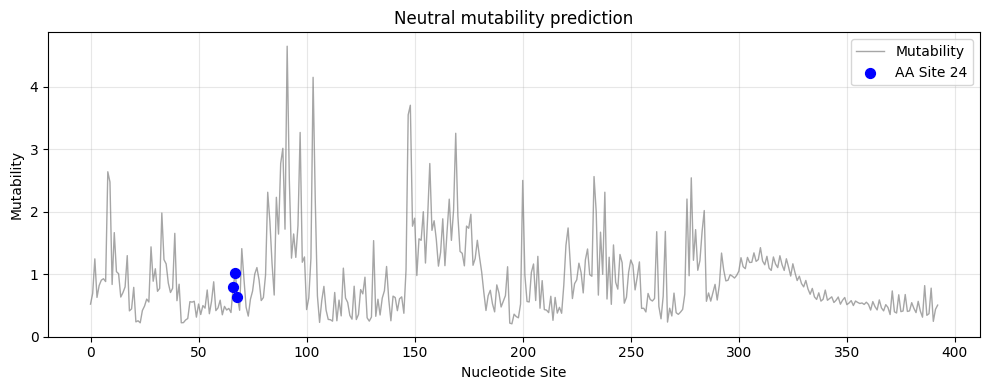

In [5]:
# the site here is not imgt aligned
pcp_v3 = MutabilityContainer.pcp_df[MutabilityContainer.pcp_df["v_gene"] == "IGHV3-23*01"]
fig = plot_mutability_with_highlights(MutabilityContainer.nuc_neutral_df[MutabilityContainer.nuc_neutral_df.pcp_index.isin(pcp_v3.index.tolist())], [24])

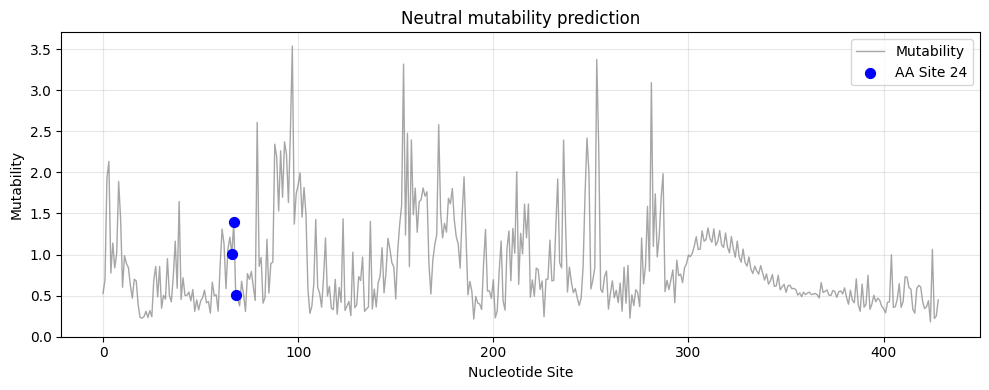

In [6]:

pcp_v4 = MutabilityContainer.pcp_df[MutabilityContainer.pcp_df["v_gene"] == "IGHV4-39*01"]
fig = plot_mutability_with_highlights(MutabilityContainer.nuc_neutral_df[MutabilityContainer.nuc_neutral_df.pcp_index.isin(pcp_v4.index.tolist())], [24])

In [7]:
single_codon_transition_df(MutabilityContainer.codon_neutral_df[MutabilityContainer.codon_neutral_df.pcp_index.isin(pcp_v3.index.tolist())], 24)


Amino acid site 24 - Top 5 most common codons:
1. GCA: 15,580 occurrences (82.0%)
2. GTA: 1,070 occurrences (5.6%)
3. GAA: 450 occurrences (2.4%)
4. ACA: 410 occurrences (2.2%)
5. GGA: 350 occurrences (1.8%)

Using most common codon: GCA
Majority: 15,580/19,010 (82.0%)
Normalized 9 transition probabilities (originally summed to 0.2243)

Found 9 possible single nucleotide transitions from GCA
Of these, 9 have observed mutations in the data


,Transition,Counts,Parent AA,Child AA,Synonymous,Probability
0,GCA (A) -> ACA (T),324,A,T,False,0.184497
1,GCA (A) -> CCA (P),9,A,P,False,0.079329
2,GCA (A) -> GAA (E),216,A,E,False,0.094131
3,GCA (A) -> GCC (A),9,A,A,True,0.048991
4,GCA (A) -> GCG (A),135,A,A,True,0.148336
5,GCA (A) -> GCT (A),81,A,A,True,0.042963
6,GCA (A) -> GGA (G),81,A,G,False,0.140754
7,GCA (A) -> GTA (V),495,A,V,False,0.209206
8,GCA (A) -> TCA (S),108,A,S,False,0.051790



Amino acid site 24 - Top 5 most common codons:
1. GCA: 15,580 occurrences (82.0%)
2. GTA: 1,070 occurrences (5.6%)
3. GAA: 450 occurrences (2.4%)
4. ACA: 410 occurrences (2.2%)
5. GGA: 350 occurrences (1.8%)

Using most common codon: GCA
Majority: 15,580/19,010 (82.0%)
Normalized 9 transition probabilities (originally summed to 0.2243)

Found 9 possible single nucleotide transitions from GCA
Of these, 9 have observed mutations in the data

Amino acid site 24 - Top 5 most common codons:
1. ACT: 7,580 occurrences (72.3%)
2. AGT: 1,160 occurrences (11.1%)
3. TCT: 410 occurrences (3.9%)
4. AAT: 330 occurrences (3.1%)
5. GCT: 280 occurrences (2.7%)

Using most common codon: ACT
Majority: 7,580/10,490 (72.3%)
Normalized 9 transition probabilities (originally summed to 0.2806)

Found 9 possible single nucleotide transitions from ACT
Of these, 9 have observed mutations in the data


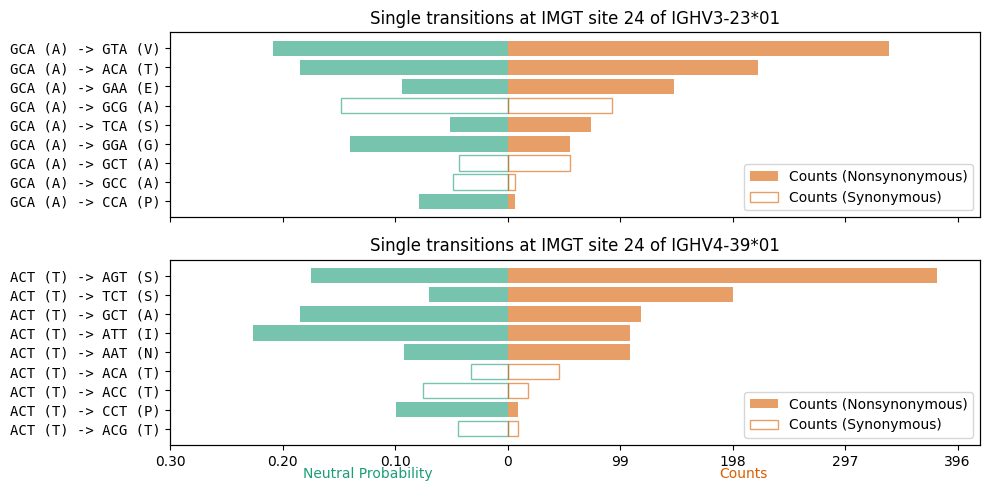

In [ ]:

mut_v3_codon_neutral_df = MutabilityContainer.codon_neutral_df[MutabilityContainer.codon_neutral_df.pcp_index.isin(pcp_v3.index.tolist())]
mut_v4_codon_neutral_df = MutabilityContainer.codon_neutral_df[MutabilityContainer.codon_neutral_df.pcp_index.isin(pcp_v4.index.tolist())]

fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# For the first plot, we need to prepare the data properly
df_v3 = single_codon_transition_df(mut_v3_codon_neutral_df, 24)  
df_v3 = df_v3[df_v3["Counts"] >= 0]

# Avoid division by zero
if df_v3["Counts"].sum() > 0:
    df_v3["Frequency"] = df_v3["Counts"] / df_v3["Counts"].sum()
    df_v3["Parent"] = df_v3["Transition"].str.extract(r'(\w+) \(')
    df_v3 = df_v3.sort_values(['Parent', 'Frequency'], ascending=[False, True], kind='mergesort')
    
    plot_codon_transitions_aux(df_v3, axs[0], show_probabilities=True, show_labels=False)

axs[0].set_title("Single transitions at IMGT site 24 of IGHV3-23*01")

# For the second plot
plot_single_codon_transitions(mut_v4_codon_neutral_df, 24, ax=axs[1])  # Replace with your actual dataframe variable
axs[1].set_title("Single transitions at IMGT site 24 of IGHV4-39*01")

plt.tight_layout()

fig.savefig(figures_dir + f"codon_transitions_23_V34.svg")

In [27]:
## look an entrenched sites
MutabilityContainer.pcp_df[MutabilityContainer.pcp_df["v_gene"].str.startswith("IGHV3")].v_gene.value_counts(ascending=False)


v_gene
IGHV3-23*01      1905
IGHV3-74*01      1082
IGHV3-7*01        909
IGHV3-7*03        662
IGHV3-33*01       633
IGHV3-21*01       498
IGHV3-15*01       463
IGHV3-9*01        444
IGHV3-53*01       392
IGHV3-30*18       312
IGHV3-48*03       286
IGHV3-48*02       264
IGHV3-11*01       176
IGHV3-72*01       176
IGHV3-49*04       169
IGHV3-23*04       158
IGHV3-73*02       136
IGHV3-48*01       132
IGHV3-30-3*01     124
IGHV3-30*03        96
IGHV3-11*06        85
IGHV3-53*02        77
IGHV3-7*05         74
IGHV3-30*02        68
IGHV3-11*04        65
IGHV3-64D*06       64
IGHV3-49*03        56
IGHV3-30*04        54
IGHV3-66*01        47
IGHV3-13*01        42
IGHV3-43*01        31
IGHV3-20*04        28
IGHV3-43*02        26
IGHV3-30*01        25
IGHV3-64*01        24
IGHV3-15*07        21
IGHV3-23*03        20
IGHV3-48*04        19
IGHV3-64D*08       18
IGHV3-53*04        17
IGHV3-33*08        16
IGHV3-49*05        14
IGHV3-73*01        14
IGHV3-21*03        13
IGHV3-43D*03       12
IGH


Amino acid site 38 - Top 5 most common codons:
1. GGC: 5,310 occurrences (83.9%)
2. GCC: 380 occurrences (6.0%)
3. GAC: 120 occurrences (1.9%)
4. ACC: 120 occurrences (1.9%)
5. AAC: 110 occurrences (1.7%)

Using most common codon: GGC
Majority: 5,310/6,330 (83.9%)
Normalized 9 transition probabilities (originally summed to 0.5953)

Found 9 possible single nucleotide transitions from GGC
Of these, 6 have observed mutations in the data

Amino acid site 38 - Top 5 most common codons:
1. GGC: 2,190 occurrences (70.2%)
2. GCT: 340 occurrences (10.9%)
3. GCC: 180 occurrences (5.8%)
4. TCT: 90 occurrences (2.9%)
5. GCA: 60 occurrences (1.9%)

Using most common codon: GGC
Majority: 2,190/3,120 (70.2%)
Normalized 9 transition probabilities (originally summed to 0.6354)

Found 9 possible single nucleotide transitions from GGC
Of these, 6 have observed mutations in the data

Amino acid site 38 - Top 5 most common codons:
1. TAC: 3,180 occurrences (81.1%)
2. TTC: 330 occurrences (8.4%)
3. CAC: 10

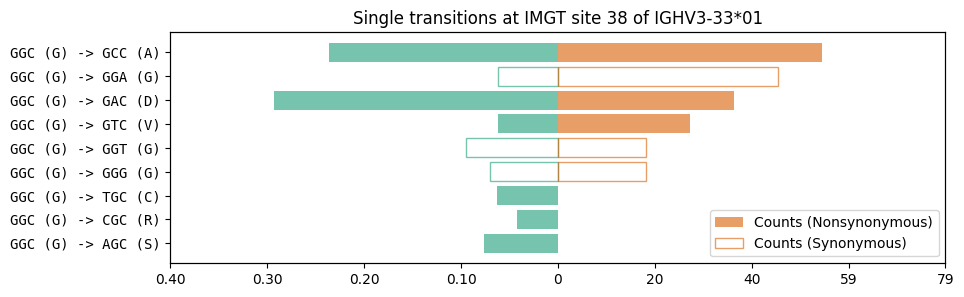

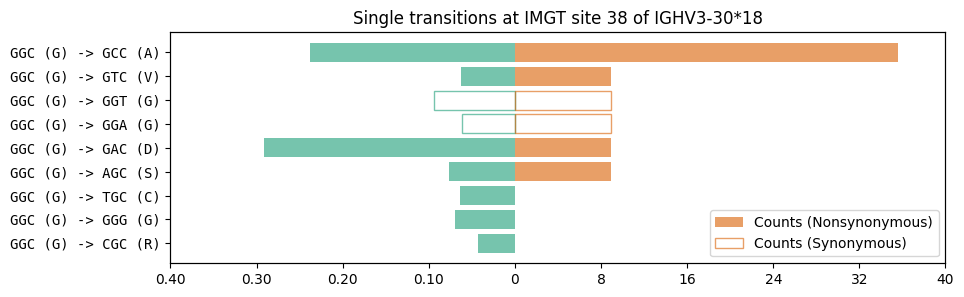

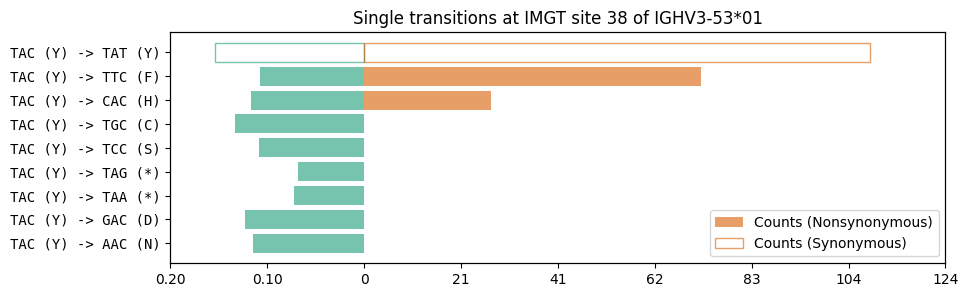

In [31]:


for v_gene in ['IGHV3-33*01', 'IGHV3-30*18', 'IGHV3-53*01']:

    pcp_for_plot = MutabilityContainer.pcp_df[MutabilityContainer.pcp_df["v_gene"] == v_gene]

    mut_for_plot_codon_neutral_df = MutabilityContainer.codon_neutral_df[MutabilityContainer.codon_neutral_df.pcp_index.isin(pcp_for_plot.index.tolist())]

    fig, ax = plt.subplots(1, 1, figsize=(10, 3))

    # For the first plot, we need to prepare the data properly
    df_v3 = single_codon_transition_df(mut_for_plot_codon_neutral_df, 38)  
    df_v3 = df_v3[df_v3["Counts"] >= 0]

    # Avoid division by zero
    if df_v3["Counts"].sum() > 0:
        df_v3["Frequency"] = df_v3["Counts"] / df_v3["Counts"].sum()
        df_v3["Parent"] = df_v3["Transition"].str.extract(r'(\w+) \(')
        df_v3 = df_v3.sort_values(['Parent', 'Frequency'], ascending=[False, True], kind='mergesort')
        
        plot_codon_transitions_aux(df_v3, ax, show_probabilities=True, show_labels=False)

    ax.set_title(f"Single transitions at IMGT site {38} of {v_gene}")



Amino acid site 9 - Top 5 most common codons:
1. GGA: 90 occurrences (100.0%)

Using most common codon: GGA
Majority: 90/90 (100.0%)
Normalized 9 transition probabilities (originally summed to 0.1445)


KeyError: "None of [Index(['Parent AA', 'Child AA'], dtype='object')] are in the [columns]"

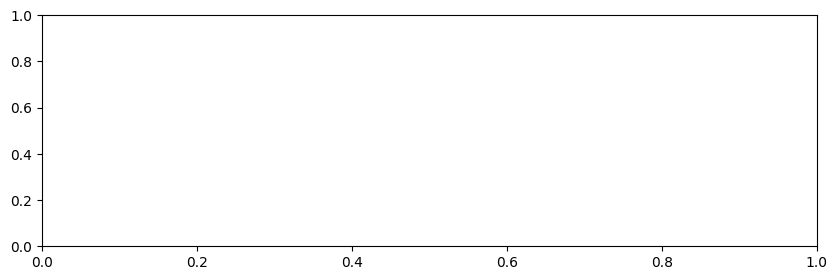

In [ ]:
pcp_for_plot = MutabilityContainer.pcp_df[MutabilityContainer.pcp_df["v_gene"] == "IGHV3-23*01"]

mut_for_plot_codon_neutral_df = MutabilityContainer.codon_neutral_df[MutabilityContainer.codon_neutral_df.pcp_index.isin(pcp_for_plot.index.tolist())]


for site in [9,17,18,30,38,39,40,46,56,57,76,82,84,97,106]:
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))

    # For the first plot, we need to prepare the data properly
    df_v3 = single_codon_transition_df(mut_for_plot_codon_neutral_df, site)  
    df_v3 = df_v3[df_v3["Counts"] >= 0]

    # Avoid division by zero
    if df_v3["Counts"].sum() > 0:
        df_v3["Frequency"] = df_v3["Counts"] / df_v3["Counts"].sum()
        df_v3["Parent"] = df_v3["Transition"].str.extract(r'(\w+) \(')
        df_v3 = df_v3.sort_values(['Parent', 'Frequency'], ascending=[False, True], kind='mergesort')
        
        plot_codon_transitions_aux(df_v3, ax, show_probabilities=True, show_labels=False)

    ax.set_title(f"Single transitions at IMGT site {site} of IGHV3-23*01")


### The nonsynonymous mutations at site 23 are not from unacknowledged germline variation

In [9]:
import pandas as pd
import requests
from Bio import SeqIO
from io import StringIO

def parse_fasta_to_df(url):
    response = requests.get(url)
    fasta_string = StringIO(response.text)

    records = list(SeqIO.parse(fasta_string, 'fasta'))

    data = []
    for record in records:
        name = record.id
        sequence = str(record.seq)
        parts = name.split('-')
        family = parts[0]
        rest = '-'.join(parts[1:]) if len(parts) > 1 else ''
        rest = rest.split('*', 1)
        gene = rest[0]
        allele = rest[1] if len(rest) > 1 else ''
        data.append({'name': name, 'sequence': sequence, 'family': family, 'gene': gene, 'allele': allele})

    # Creating DataFrame
    df = pd.DataFrame(data)
    return df

fasta_url = 'https://raw.githubusercontent.com/psathyrella/partis/main/data/germlines/human/igh/ighv.fasta'

# Parsing and displaying the DataFrame
germline_df = parse_fasta_to_df(fasta_url)
site = 23
germline_df[f"{site}th codon"] = germline_df["sequence"].apply(lambda x: x[3*(site-1):3*site])
# make a dataframe of germline_df[f'{site}th codon'].value_counts()
codon_df = germline_df[f"{site}th codon"].value_counts().reset_index()
codon_df
codon_df[f"{site}th AA"] = codon_df[f"{site}th codon"].apply(codon_to_aa)
codon_df
# reorder with count last
codon_df = codon_df[[f"{site}th codon", f"{site}th AA", "count"]]
codon_df

,23th codon,23th AA,count
0,GCA,A,87
1,AAG,K,52
2,ACT,T,23
3,GCT,A,17
4,ACC,T,11
5,ACA,T,3
6,TCA,S,3
7,GCC,A,2


In [10]:
germline_df[germline_df["23th codon"] == "TCA"]

,name,sequence,family,gene,allele,23th codon
120,IGHV3-64D*06,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,IGHV3,64D,06,TCA
121,IGHV3-64D*08,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,IGHV3,64D,08,TCA
122,IGHV3-64D*09,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,IGHV3,64D,09,TCA


In [11]:
germline_df[germline_df["name"].str.startswith("IGHV3-64D")]

,name,sequence,family,gene,allele,23th codon
120,IGHV3-64D*06,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,IGHV3,64D,06,TCA
121,IGHV3-64D*08,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,IGHV3,64D,08,TCA
122,IGHV3-64D*09,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,IGHV3,64D,09,TCA


## Buried vs exposed analysis

In [12]:
# Site definitions and numbering
# Below we skip 118 because it's not encoded by the V gene, and 52 because it's a W amino acid 
# that has only one codon (doesn't make sense to do syn/nonsyn comparison).
buried_sites, exposed_sites = ([87, 78, 105, 76], [16, 9, 8, 7])


def plot_codon_transitions_stack(codon_neutral_df, site_list, title_suffix=""):
    """
    Create a stack of plots for all sites in the dictionary.
    
    Parameters:
    - codon_neutral_df: DataFrame with codon neutral data
    - site_dict: Dictionary mapping IMGT sites to regular sites
    - title_suffix: String to add to plot titles (e.g., "of IGHV3-23*01")
    """
    n_sites = len(site_list)
    fig, axes = plt.subplots(n_sites, 1, figsize=(10, 3 * n_sites))
    
    # Handle case where there's only one site (axes won't be an array)
    if n_sites == 1:
        axes = [axes]
    
    for i, site in enumerate(site_list):
        plot_single_codon_transitions(codon_neutral_df, site, ax=axes[i], min_count=0)
        axes[i].set_title(f"Single transitions at IMGT site {site}{title_suffix}")
        
        # Suppress x-axis labels for all except the bottom plot
        if i < n_sites - 1:
            axes[i].set_xlabel("")
                
    
    plt.tight_layout()
    return fig




Amino acid site 87 - Top 5 most common codons:
1. CTG: 12,440 occurrences (65.4%)
2. GTG: 2,300 occurrences (12.1%)
3. TTG: 880 occurrences (4.6%)
4. CTC: 760 occurrences (4.0%)
5. CTA: 740 occurrences (3.9%)

Using most common codon: CTG
Majority: 12,440/19,010 (65.4%)
Normalized 9 transition probabilities (originally summed to 0.3999)

Found 9 possible single nucleotide transitions from CTG
Of these, 8 have observed mutations in the data

Amino acid site 78 - Top 5 most common codons:
1. ATC: 16,130 occurrences (84.9%)
2. GTC: 1,590 occurrences (8.4%)
3. ATT: 310 occurrences (1.6%)
4. ATG: 270 occurrences (1.4%)
5. ACC: 210 occurrences (1.1%)

Using most common codon: ATC
Majority: 16,130/19,010 (84.9%)
Normalized 9 transition probabilities (originally summed to 0.2599)

Found 9 possible single nucleotide transitions from ATC
Of these, 8 have observed mutations in the data

Amino acid site 105 - Top 5 most common codons:
1. GCG: 15,850 occurrences (83.4%)
2. GTG: 1,120 occurrences (

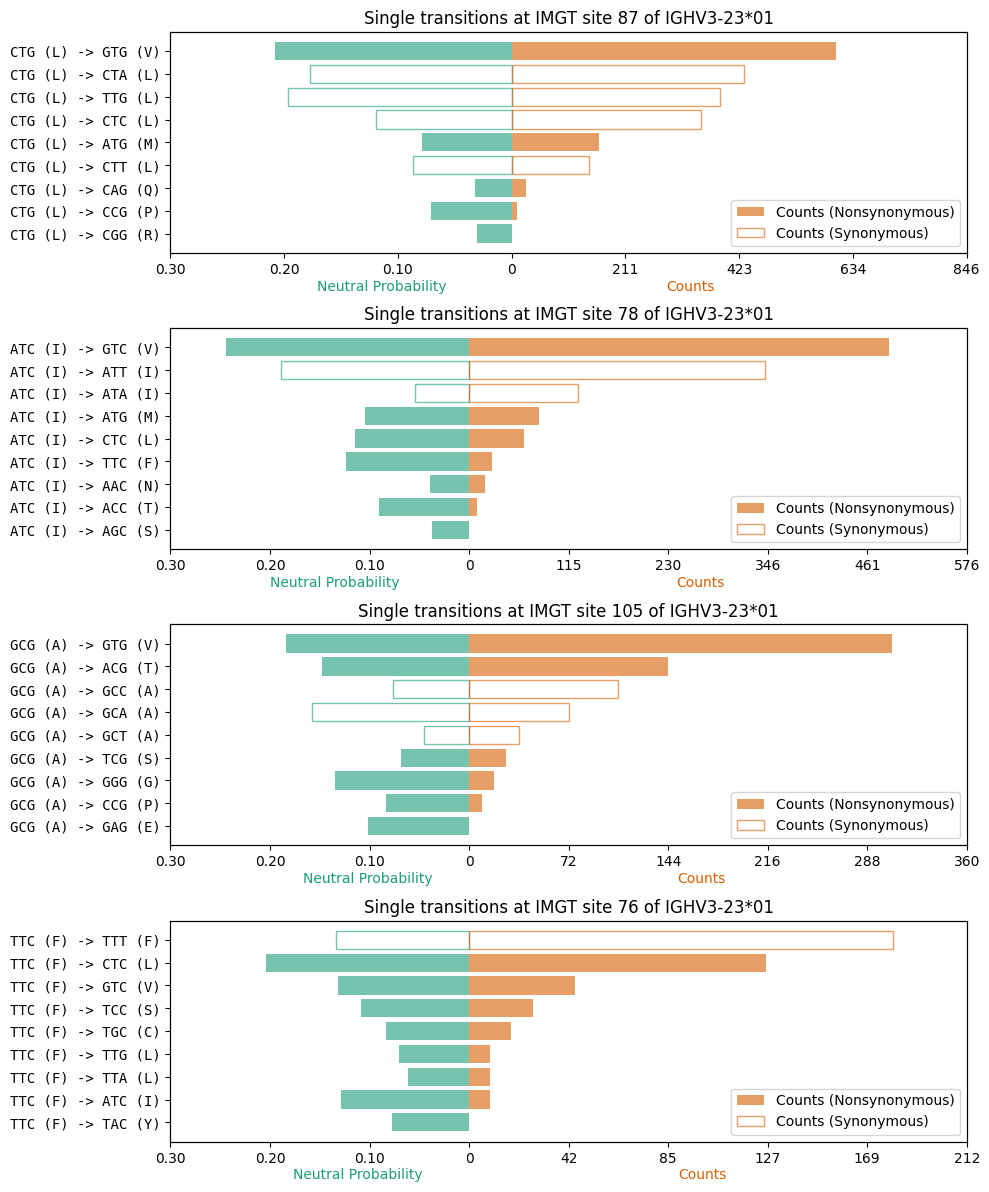

In [13]:
buried_fig = plot_codon_transitions_stack(
    mut_v3_codon_neutral_df,  # Replace with your actual variable name
    buried_sites, 
    title_suffix=" of IGHV3-23*01"
)
buried_fig.savefig(figures_dir + "codon_transitions_buried_V3.svg")


Amino acid site 16 - Top 5 most common codons:
1. GGG: 18,540 occurrences (97.5%)
2. GGA: 380 occurrences (2.0%)
3. GGT: 50 occurrences (0.3%)
4. GCG: 20 occurrences (0.1%)
5. GAG: 20 occurrences (0.1%)

Using most common codon: GGG
Majority: 18,540/19,010 (97.5%)
Normalized 9 transition probabilities (originally summed to 0.0681)

Found 9 possible single nucleotide transitions from GGG
Of these, 4 have observed mutations in the data

Amino acid site 9 - Top 5 most common codons:
1. GGA: 18,780 occurrences (98.8%)
2. GGG: 80 occurrences (0.4%)
3. GGC: 50 occurrences (0.3%)
4. CAA: 50 occurrences (0.3%)
5. GAA: 40 occurrences (0.2%)

Using most common codon: GGA
Majority: 18,780/19,010 (98.8%)
Normalized 9 transition probabilities (originally summed to 0.1470)

Found 9 possible single nucleotide transitions from GGA
Of these, 3 have observed mutations in the data

Amino acid site 8 - Top 5 most common codons:
1. GGG: 18,700 occurrences (98.4%)
2. GGA: 220 occurrences (1.2%)
3. GAG: 70 

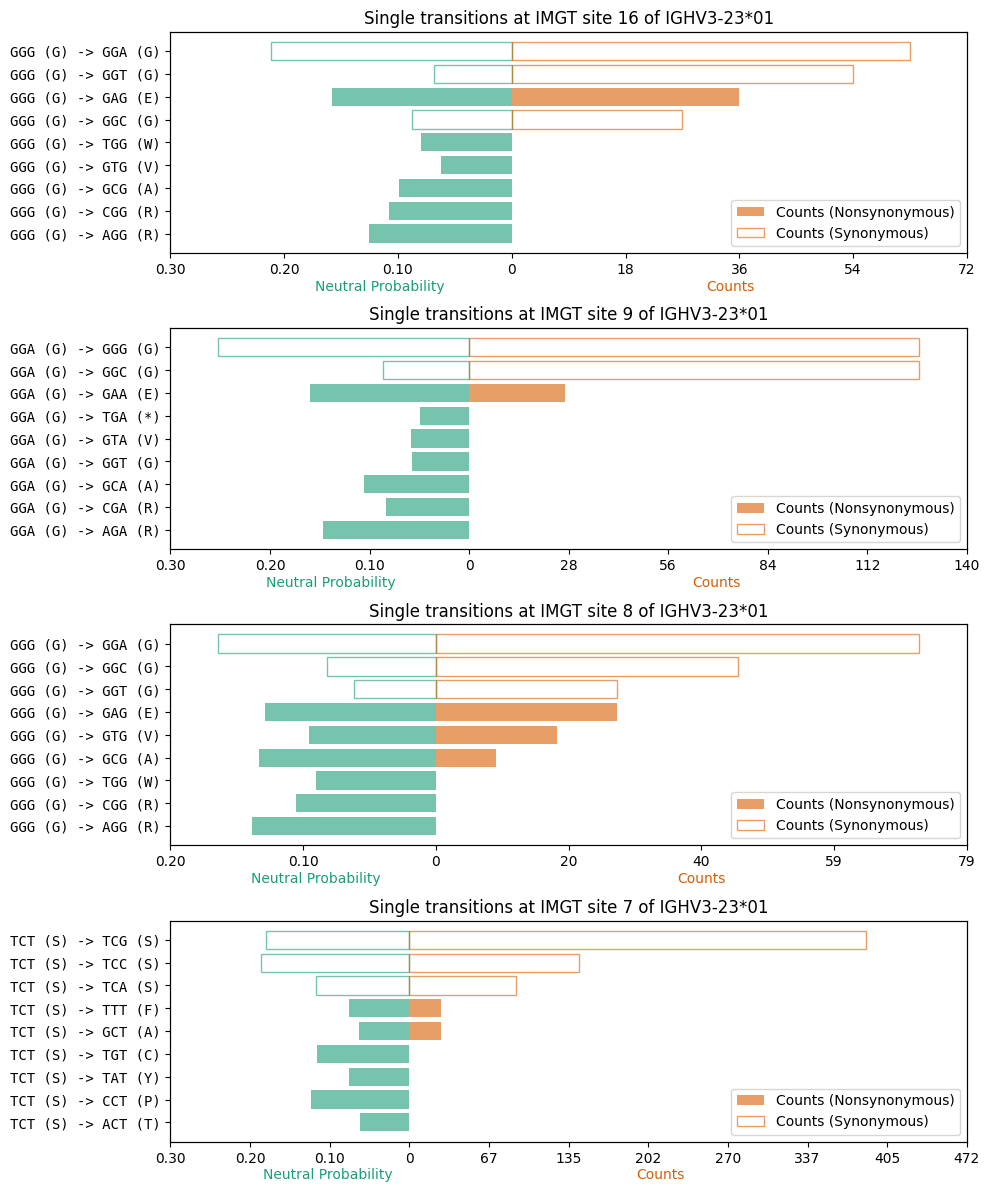

In [14]:
exposed_fig = plot_codon_transitions_stack(
    mut_v3_codon_neutral_df,  # Replace with your actual variable name
    exposed_sites, 
    title_suffix=" of IGHV3-23*01"
)
exposed_fig.savefig(figures_dir + "codon_transitions_exposed_V3.svg")


Amino acid site 87 - Top 5 most common codons:
1. CTG: 12,440 occurrences (65.4%)
2. GTG: 2,300 occurrences (12.1%)
3. TTG: 880 occurrences (4.6%)
4. CTC: 760 occurrences (4.0%)
5. CTA: 740 occurrences (3.9%)

Using most common codon: CTG
Majority: 12,440/19,010 (65.4%)
Normalized 9 transition probabilities (originally summed to 0.3999)

Found 9 possible single nucleotide transitions from CTG
Of these, 8 have observed mutations in the data


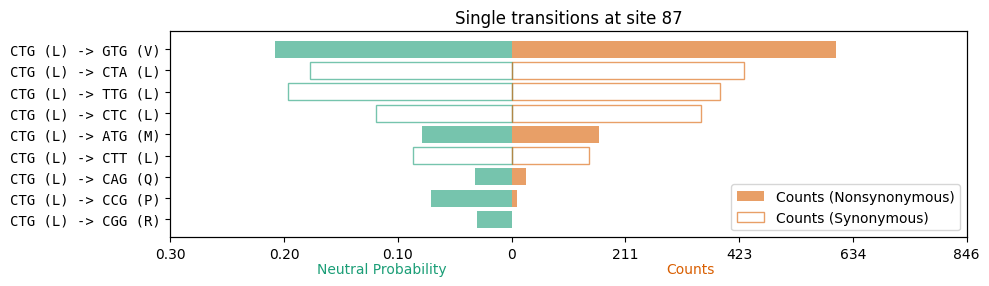

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))


plot_single_codon_transitions(mut_v3_codon_neutral_df, 87, ax=ax)  # Replace with your actual dataframe variable
axs[1].set_title("Single transitions at IMGT site 87 of IGHV3-23*01")

plt.tight_layout()

fig.savefig(figures_dir + f"codon_transitions_79_V3.svg")